# Feature Engineering

## Imports and functions

In [1]:
# Imports
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def plot_distribution(df, column, bins=30):
    """
    Plot the distribution of a numerical feature using a histogram and KDE.
    """

    data = df[column]

    plt.figure(figsize=(8,5))

    sns.histplot(data, bins=bins, kde=True)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.show()


def plot_survival_rate(df, column):
    """
    Plot survival counts grouped by a categorical feature.
    """

    plt.figure(figsize=(8,5))

    sns.countplot(x=column, hue="Survived", data=df)

    plt.title(f"Survival by {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.legend(title="Survived")

    plt.show()

In [3]:
# Load
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

train_bkp = train.copy()
test_bkp = test.copy()

## Dropping unused features

In [4]:
train.drop(columns=['PassengerId', 'Ticket'], inplace=True)

## FamilySize

This feature was engineered to investigate whether family size significantly impacted survival probability.

In [5]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

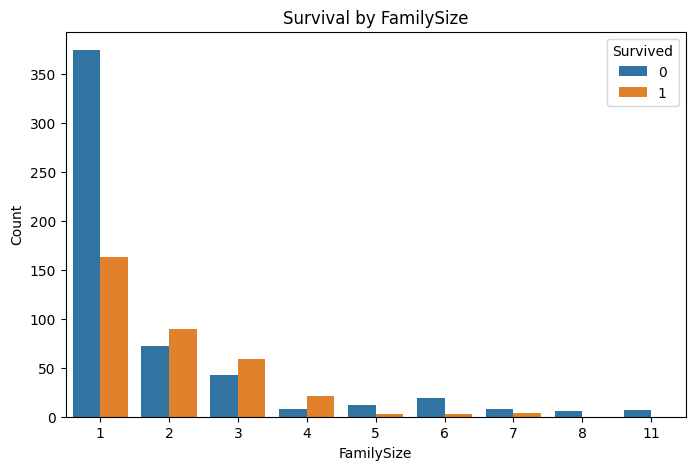

In [6]:
plot_survival_rate(train,'FamilySize')

Small families have a better chance of survival compared to large families or lonely passengers.

## HasCabin

I will create a binary indicator feature to distinguish between passengers with known and unknown cabin assignments, capturing potential survival bias related to data availability.

In [7]:
train["HasCabin"] = train["Cabin"].notna().astype(int)

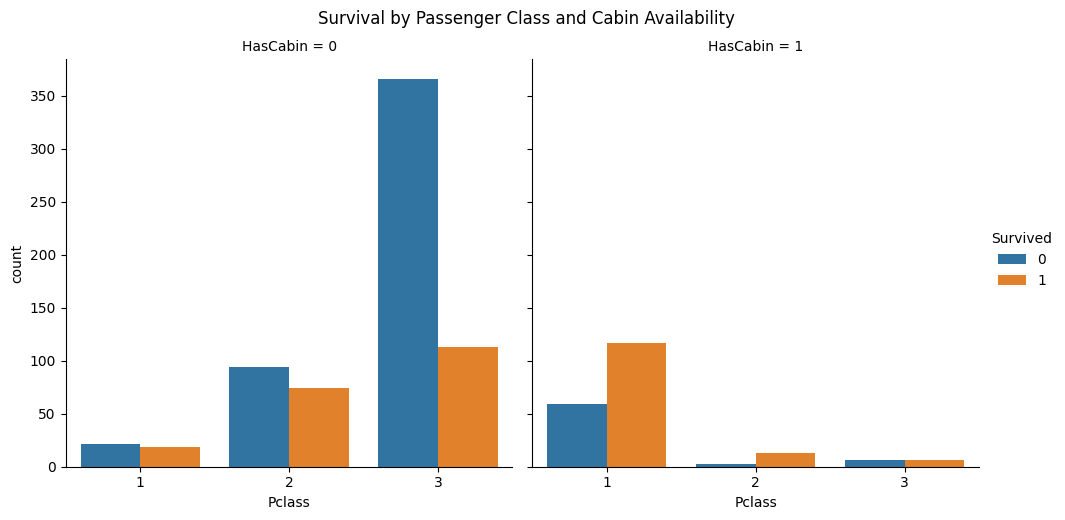

In [21]:
sns.catplot(x="Pclass", hue="Survived", col="HasCabin", data=train, kind="count", height=5)
plt.suptitle("Survival by Passenger Class and Cabin Availability", y=1.03)
plt.show()

This feature clearly indicates that passengers with recorded cabin information had a higher chance of survival.

## Deck extraction


The `Cabin` column contains structural information about the ship's decks. To evaluate its impact on survival, I will extract this data into a new feature called `Deck`.

Due to the high percentage of missing values, I will categorize all unidentified records as 'U' (Unknown) to maintain dataset integrity.

In [9]:
train['Deck'] = train['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')

I am implementing a direct mapping from the `Deck` strings to an ordinal `Deck_Level` feature.\
By converting these values to integers immediately, I ensure the model captures the ship's vertical hierarchy while keeping the dataset concise.

In [10]:
DECKS = {
    'U': 0,
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
    'G': 7,
    'T': 8,
}
train['Deck_Level'] = train['Deck'].map(DECKS)
train.drop(columns=['Deck', 'Cabin'], inplace=True)

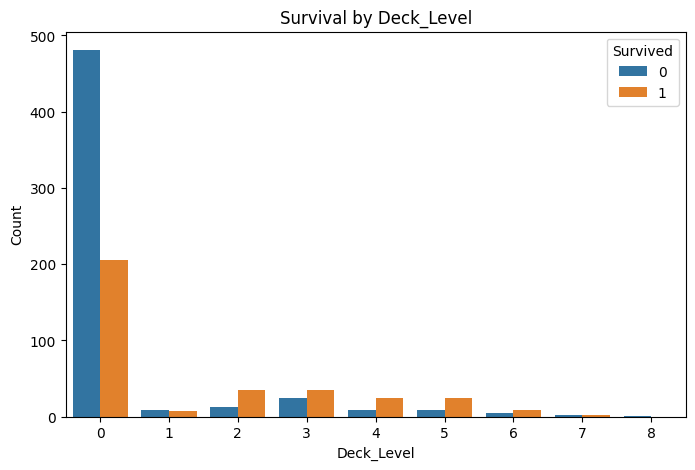

In [11]:
plot_survival_rate(train,'Deck_Level')

Central decks exhibit a higher probability of survival, likely due to their physical proximity to the lifeboats and primary evacuation routes.

## Sex

I will apply Label Encoding to the Sex feature, as it is a binary variable.

In [12]:
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})

## One-Hot Encoding

I will apply One-Hot Encoding to categorical variables to transform them into a numerical format, ensuring the machine learning algorithms can correctly interpret these features without implying an ordinal relationship.

I will use the `drop_first=True` parameter to avoid the dummy variable trap and reduce multicollinearity within the feature set.

In [13]:
train = pd.get_dummies(train, columns=["Embarked"], drop_first=True)

## Age

I will utilize the 'Master' title as a proxy to impute missing values in the `Age` column for young male passengers.\
Once the imputation is complete, the `Name` feature will be dropped to streamline the dataset for training.

In [14]:
master_medians = train[train['Name'].str.contains('Master')].groupby('Pclass')['Age'].median()

for pclass, median_age in master_medians.items():
    mask = (train['Age'].isnull()) & (train['Name'].str.contains('Master')) & (train['Pclass'] == pclass)
    train.loc[mask, 'Age'] = median_age

train.drop(columns=['Name'], inplace=True)

To further refine the imputation of missing ages, I will use the median age calculated by both Pclass and Sex.\
This granular approach accounts for gender-based age distributions within each socio-economic tier, resulting in more representative imputed values.

In [15]:
train['Age'] = train['Age'].fillna(train.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

## Fare per person

By normalizing the `Fare` by `FamilySize`, we can observe the impact of individual ticket costs.\
This visualization helps identify if outliers (extremely high fares) or group-based pricing influenced evacuation priority.

In [16]:
train['Fare_Per_Person']=train['Fare']/train['FamilySize']

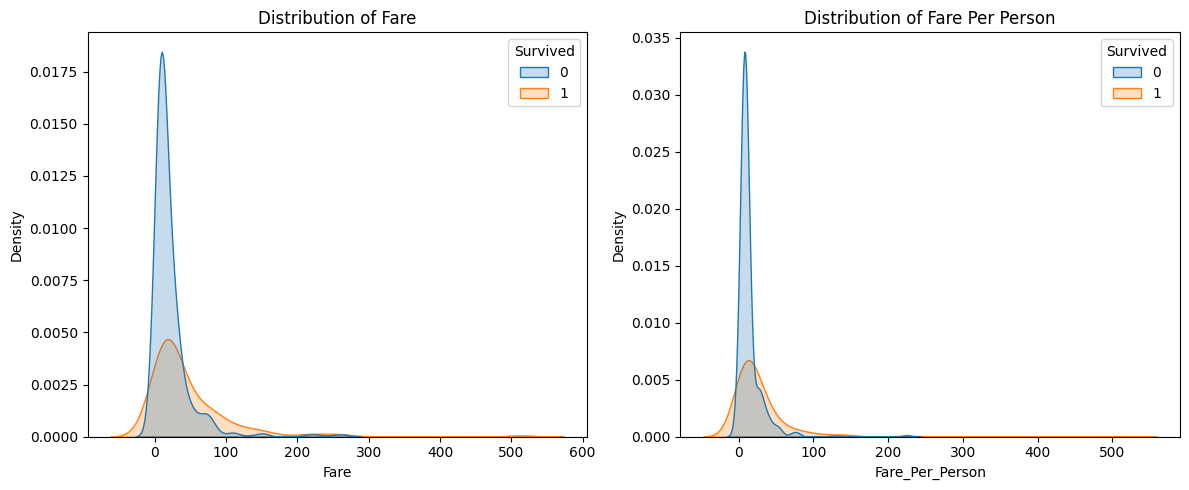

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(data=train, x='Fare', hue='Survived', fill=True, ax=axes[0])
axes[0].set_title('Distribution of Fare')

sns.kdeplot(data=train, x='Fare_Per_Person', hue='Survived', fill=True, ax=axes[1])
axes[1].set_title('Distribution of Fare Per Person')

plt.tight_layout()
plt.show()

Although the KDE plots for `Fare` and `Fare_Per_Person` exhibit similar distributions, the engineered feature provides a more accurate representation of individual socioeconomic standing by normalizing costs across family units.\
*I will retain `Fare_Per_Person` and drop the raw `Fare` variable to reduce redundancy and allow the model to learn from normalized financial signals.*

## IsAlone

I created `IsAlone` to capture the binary distinction between solo travelers and groups.\
While `FamilySize` provides granular data, `IsAlone` simplifies the feature space, allowing the model to focus on the significant survival gap between these two primary categories without the noise of specific family counts.

In [18]:
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)

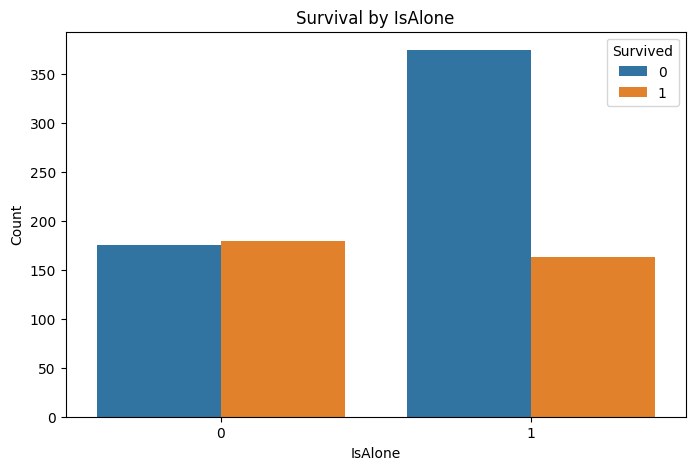

In [19]:
plot_survival_rate(train,'IsAlone')

## Notes

I have decided to exclude passenger titles from the feature set.\
Preliminary analysis suggests that the information provided by titles is redundant, as it is already largely captured by the `Sex` and `Age` variables.

Dev notes: 
- Test the models using one-hot enconding in Deck feature.
- Test filling Unknown decks with the MODE value of its class.
- Fare_Per_Person increases model accuracy?